# vilip1 SAE: training curves + benchmark vs. Biohub's general SAE (65k-dataset run)

Same pipeline as the original 4096-dict proof-of-concept (see
`sae_benchmark_analysis.ipynb`), rerun on the larger "65k" training dataset
(`checkpoints_65k/run1`) -- dict size is still 4096 (`d_hidden` unchanged;
"65k" names the training-dataset size, not the dictionary size), but the
manifest now includes a third design source (`composite_hotspot_20260728`)
and a bigger eval-only natural-binder set (82 real UniProt sequences: 13
hand-picked `natural_binders` + 69 more from STRING functional/physical
association data, `binder_dataset_vilip1`).

Two things in this notebook:
1. **Training diagnostics** for our domain-specific SAE (layer 23, k=64,
   dictionary=4096) -- loss/FVE/dead-feature curves over the 50-epoch run,
   from `training_log.csv`.
2. **Benchmark**: our trained SAE vs. Biohub's official general-purpose
   ESMC-300M SAE (`biohub/ESMC-300M-sae-k64-codebook16384`, also layer 23,
   dictionary=16384), evaluated on the identical held-out residues --
   from `benchmark_summary.csv` (produced by `sae/04_benchmark/benchmark.py`,
   using Biohub's official `add_sae_models` encode path + their published
   decoder weights, verified against their real installed source code, not
   a guessed formula).

NOTE: this notebook lives at `sae/notebooks/` -- two directories deep from
the repo root, so data paths need `../../`, not `../`.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TRAINING_LOG_PATH = "../../checkpoints_65k/run1/training_log.csv"
BENCHMARK_PATH = "../../benchmark_results_65k/benchmark_summary.csv"
OUTPUT_DIR = "../../vilip1_65k_sae_outputs/analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)


## Training curves (our model, 50 epochs)

In [2]:
log = pd.read_csv(TRAINING_LOG_PATH)
print(f"{len(log)} epochs logged")
log.tail()

50 epochs logged


,epoch,train_mse,train_auxk_loss,val_fve_pooled,val_avg_l0_pooled,num_dead,val_fve_composite_hotspot,val_fve_composite_hotspot_20260728,val_fve_vilip1_full20k,val_avg_l0_composite_hotspot,val_avg_l0_composite_hotspot_20260728,val_avg_l0_vilip1_full20k
45,45,0.041157,0.000040,0.965567,63.999907,0,0.972824,0.971130,0.906699,63.999905,63.999882,64.0
46,46,0.041151,0.000039,0.965584,63.999879,0,0.972841,0.971145,0.906744,63.999825,63.999854,64.0
47,47,0.041143,0.000031,0.965572,63.999802,0,0.972822,0.971137,0.906699,63.999730,63.999759,64.0
48,48,0.041140,0.000042,0.965599,63.999543,0,0.972853,0.971156,0.906799,63.999571,63.999419,64.0
49,49,0.041133,0.000032,0.965581,63.999826,0,0.972837,0.971148,0.906682,63.999841,63.999779,64.0


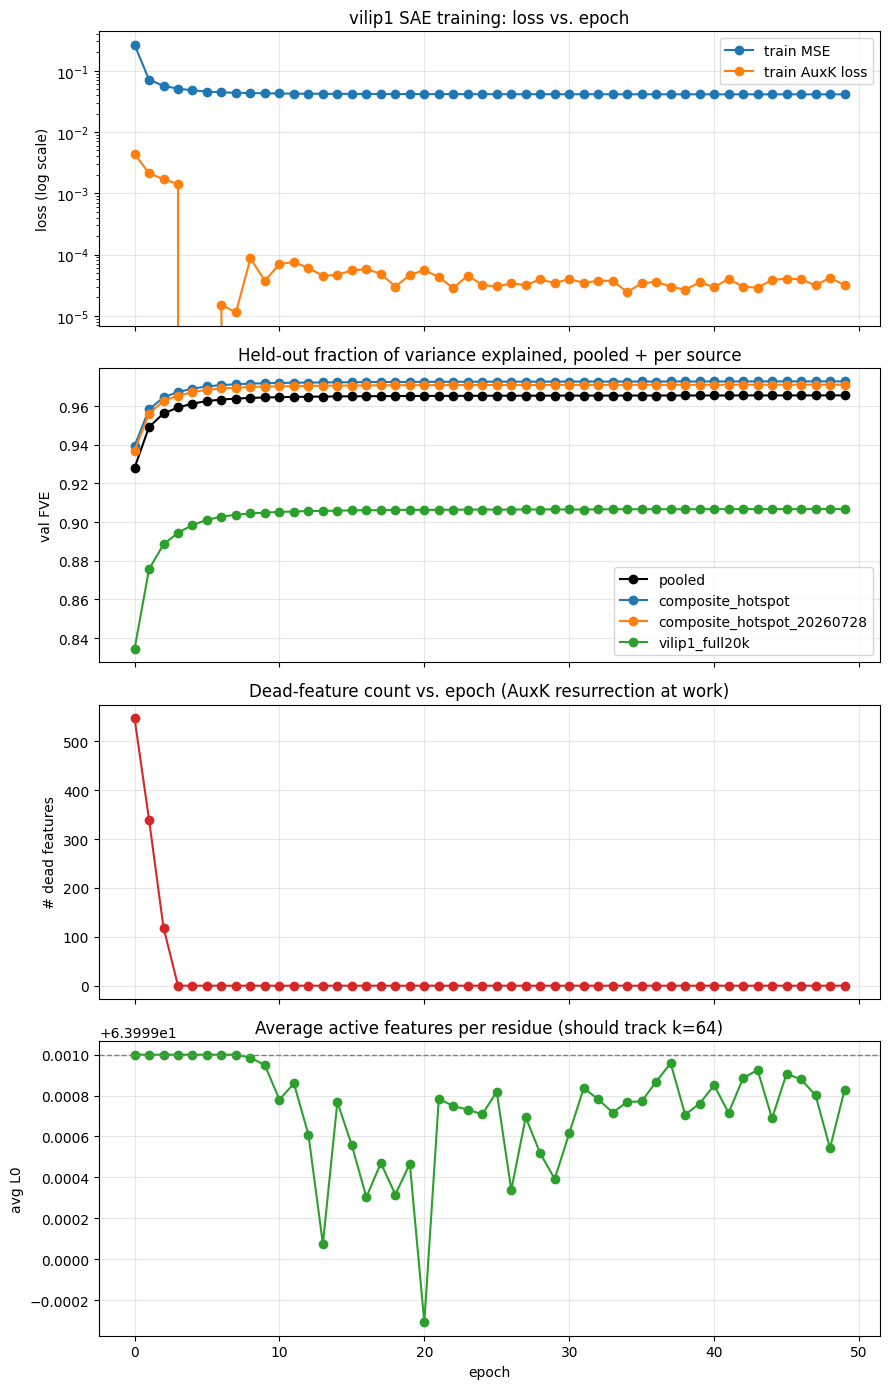

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(9, 14), sharex=True)

axes[0].plot(log["epoch"], log["train_mse"], marker="o", label="train MSE")
axes[0].plot(log["epoch"], log["train_auxk_loss"], marker="o", label="train AuxK loss")
axes[0].set_yscale("log")
axes[0].set_ylabel("loss (log scale)")
axes[0].set_title("vilip1 SAE training: loss vs. epoch")
axes[0].legend()

axes[1].plot(log["epoch"], log["val_fve_pooled"], marker="o", color="black", label="pooled")
axes[1].plot(log["epoch"], log["val_fve_composite_hotspot"], marker="o", label="composite_hotspot")
axes[1].plot(log["epoch"], log["val_fve_composite_hotspot_20260728"], marker="o", label="composite_hotspot_20260728")
axes[1].plot(log["epoch"], log["val_fve_vilip1_full20k"], marker="o", label="vilip1_full20k")
axes[1].set_ylabel("val FVE")
axes[1].set_title("Held-out fraction of variance explained, pooled + per source")
axes[1].legend()

axes[2].plot(log["epoch"], log["num_dead"], marker="o", color="tab:red")
axes[2].set_ylabel("# dead features")
axes[2].set_title("Dead-feature count vs. epoch (AuxK resurrection at work)")

axes[3].plot(log["epoch"], log["val_avg_l0_pooled"], marker="o", color="tab:green")
axes[3].set_ylabel("avg L0")
axes[3].set_xlabel("epoch")
axes[3].set_title("Average active features per residue (should track k=64)")
axes[3].axhline(64, color="gray", linestyle="--", linewidth=1)

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=200)
plt.show()


In [4]:
print("Summary: epoch 0 ->", log['epoch'].iloc[-1])
print(f"  train_mse: {log['train_mse'].iloc[0]:.4f} -> {log['train_mse'].iloc[-1]:.4f}")
print(f"  val_fve_pooled: {log['val_fve_pooled'].iloc[0]:.4f} -> {log['val_fve_pooled'].iloc[-1]:.4f}")
print(f"  num_dead: {log['num_dead'].iloc[0]:.0f} -> {log['num_dead'].iloc[-1]:.0f}")
print(f"  val_fve_composite_hotspot: {log['val_fve_composite_hotspot'].iloc[0]:.4f} -> {log['val_fve_composite_hotspot'].iloc[-1]:.4f}")
print(f"  val_fve_composite_hotspot_20260728: {log['val_fve_composite_hotspot_20260728'].iloc[0]:.4f} -> {log['val_fve_composite_hotspot_20260728'].iloc[-1]:.4f}")
print(f"  val_fve_vilip1_full20k: {log['val_fve_vilip1_full20k'].iloc[0]:.4f} -> {log['val_fve_vilip1_full20k'].iloc[-1]:.4f}")


Summary: epoch 0 -> 49
  train_mse: 0.2658 -> 0.0411
  val_fve_pooled: 0.9281 -> 0.9656
  num_dead: 548 -> 0
  val_fve_composite_hotspot: 0.9394 -> 0.9728
  val_fve_composite_hotspot_20260728: 0.9370 -> 0.9711
  val_fve_vilip1_full20k: 0.8343 -> 0.9067


## Benchmark: ours vs. Biohub's general SAE

Both evaluated on the exact same held-out residues (696,005 held-out design
residues, stratified 90/10 split done in `data.py` across three sources --
`vilip1_full20k`, `composite_hotspot`, `composite_hotspot_20260728` --
never seen during our training) plus the 41,231-residue eval-only set (82
real UniProt sequences: 13 `natural_binders` + 69 `binder_dataset_vilip1`
from STRING, never used for anything except this qualitative pass). FVE
computed against a shared baseline (our checkpoint's train-set mean, not a
naive zero baseline -- see project notes on why raw-zero FVE is inflated by
ESM-C's large outlier activation dimensions).


In [5]:
bench = pd.read_csv(BENCHMARK_PATH)
bench

,split,model,source,n_residues,fve,avg_l0,n_dead,dict_size
0,held_out_designs,ours,__pooled__,696005,0.965583,63.999514,0,4096
1,held_out_designs,biohub,__pooled__,696005,0.680455,64.000000,921,16384
2,held_out_designs,ours,vilip1_full20k,131804,0.906707,64.000000,1,4096
3,held_out_designs,biohub,vilip1_full20k,131804,0.814907,64.000000,3023,16384
4,held_out_designs,ours,composite_hotspot,62922,0.972853,63.999555,3,4096
5,held_out_designs,biohub,composite_hotspot,62922,0.667324,64.000000,3997,16384
6,held_out_designs,ours,composite_hotspot_20260728,501279,0.971149,63.999382,0,4096
7,held_out_designs,biohub,composite_hotspot_20260728,501279,0.667304,64.000000,1327,16384
8,natural_binders_qualitative,ours,__pooled__,41231,0.385148,64.000000,1,4096
9,natural_binders_qualitative,biohub,__pooled__,41231,0.703617,64.000000,662,16384


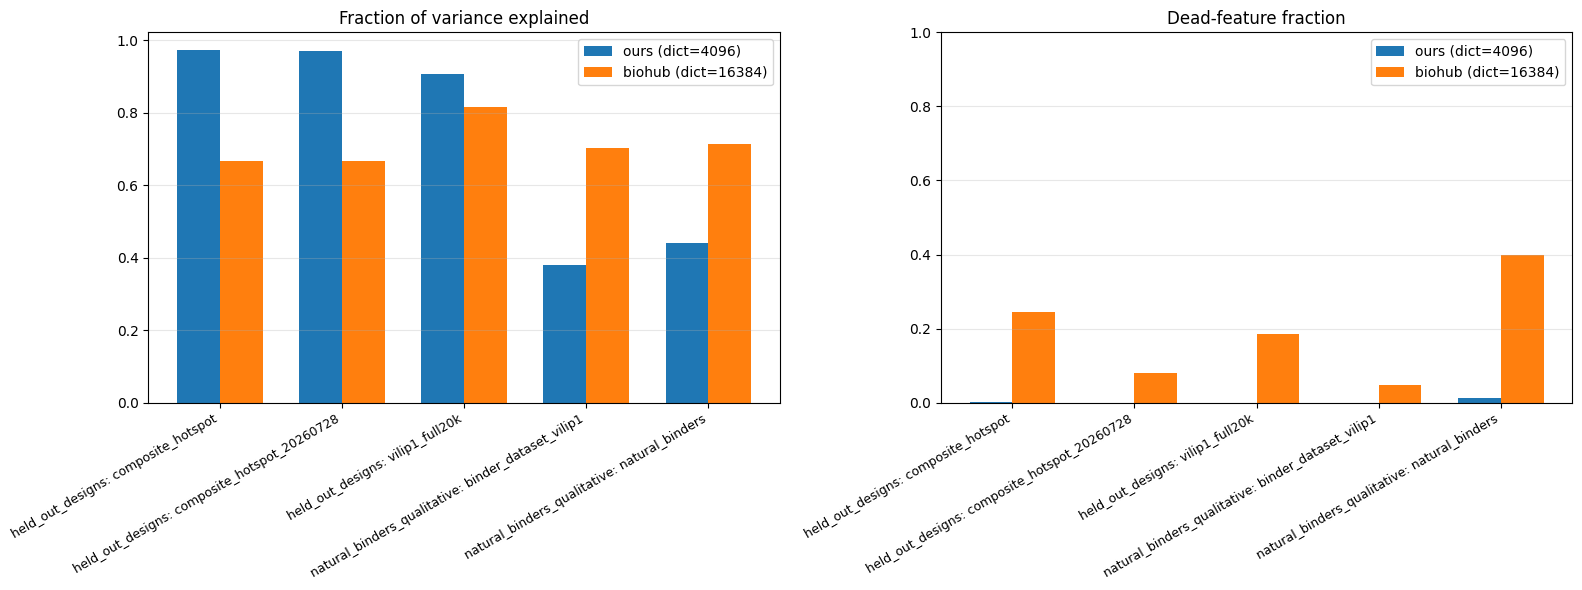

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_df = bench[bench["source"] != "__pooled__"].copy()
plot_df["group"] = plot_df["split"] + ": " + plot_df["source"]

groups = sorted(plot_df["group"].unique())
x = np.arange(len(groups))
width = 0.35

for ax, metric, title in [
    (axes[0], "fve", "Fraction of variance explained"),
    (axes[1], None, "Dead-feature fraction"),
]:
    for i, model in enumerate(["ours", "biohub"]):
        sub = plot_df[plot_df["model"] == model].set_index("group").reindex(groups)
        if metric == "fve":
            values = sub["fve"]
        else:
            values = sub["n_dead"] / sub["dict_size"]
        ax.bar(x + i * width, values, width, label=f"{model} (dict={sub['dict_size'].iloc[0]})")
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(groups, rotation=30, ha="right", fontsize=9)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3, axis="y")

axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/benchmark_comparison.png", dpi=200)
plt.show()


## Takeaways

- **On the actual design domain** (held_out_designs, 696,005 residues never
  seen in training): our domain-specific SAE clearly outperforms Biohub's
  general SAE (FVE 0.9656 vs. 0.6805) and uses its much smaller dictionary
  far more completely (0/4096 dead vs. 921/16384 dead for Biohub).
- **On real, out-of-domain proteins** (natural_binders_qualitative, 41,231
  residues across 82 UniProt sequences never used in training at all): the
  result flips -- Biohub's general SAE generalizes much better (FVE 0.7036
  vs. 0.3851) since it was trained broadly on UniRef90, while ours only ever
  saw synthetic Boltz-designed vilip1 binders.
- Same specialist/generalist trade-off as the original 4096-dict
  proof-of-concept, holding up on a larger training set and a much bigger
  (13 -> 82 sequence) out-of-domain eval set. Biohub's dead-feature count on
  the eval set is far lower here (662/16384 pooled) than in the original run
  (6522/16384 on just the 13 natural binders) simply because the eval set is
  now 6x bigger and exercises more of its dictionary -- not evidence of a
  better model, just more eval coverage.
